# The right edge of the exclusion: a flux-through-aperture cut

**Paper element.** The high-mass end of the mass window — the cut
$m_\mathrm{cut}$ quoted in Results and stored in the release attributes.

**Private, pedagogical.** The companion to
[`10_left_edge_anatomy.ipynb`](10_left_edge_anatomy.ipynb), which does the same
job for the other end. Everything below reads the
released cubes `luhdm_datarelease_v8_A_f1_atm.h5` ($f_\mathrm{DM} = 1$) and
`luhdm_datarelease_v8_B_f0p1_noatm.h5` ($f_\mathrm{DM} = 0.1$). Section 3 also
quotes two closure masses from the superseded capped analysis; that cube is an
internal file and not part of the release, so the two numbers are carried here
as frozen constants with their provenance recorded beside them. Every band drawn
below is **mode 1**, the mode the Letter's mass window is quoted from.

The left edge is kinematic: below $m_\mathrm{wall}$ no flyby can reach the
analysis window. The right edge is not kinematic at all. A heavier particle
delivers a *harder* kick, so nothing in the cross section stops the exclusion
from running to the Planck mass — and on the released surfaces it does exactly
that: the massless-mediator band is still excluded at the last mass on the grid.
What runs out is the *supply*. At fixed local density $\rho_0$ the number
density falls as $1/m_\mathrm{DM}$, so a heavy enough particle simply does not
pass close to the sensor during the exposure, however strongly it couples when
it does.

Made quantitative over an aperture of radius $b_\mathrm{cap}$,

$$N(m_\mathrm{DM}) \;=\; f_\mathrm{DM}\,\frac{\rho_0}{m_\mathrm{DM}}\,
\langle v \rangle\, T_\mathrm{obs}\, \pi\, b_\mathrm{cap}^{2},$$

with $\rho_0 = 0.3$ GeV/cm$^3$, $\langle v \rangle$ the flux-weighted mean halo
speed and $T_\mathrm{obs}$ the exposure. $N$ falls as $1/m_\mathrm{DM}$, so
demanding at least $N_\mathrm{req}$ transits sets a largest mass

$$m_\mathrm{cut} \;=\; \frac{f_\mathrm{DM}\,\rho_0\,\langle v \rangle\,
T_\mathrm{obs}\,\pi\,b_\mathrm{cap}^{2}}{N_\mathrm{req}} .$$

This is a statement about the flux, not about the cross section, which is why it
is applied as a *post-facto* cut in mass rather than as a cap inside the
impact-parameter integral. The stored $\mu$ and extremeness surfaces are
uncapped and auditable; $m_\mathrm{cut}$ is a line drawn on top of them, and a
reader who disagrees with the choice of $N_\mathrm{req}$ can move it.

**The assumption, stated up front.** The released files carry
$N_\mathrm{req} = 3$, matching the Poisson-zero standard the limit itself uses
($-\ln 0.05 = 3.0$ expected counts). That choice is an assumption, not a
derivation. The alternative kept in view throughout is $N_\mathrm{req} = 6.8$,
the value that reproduces the closure of the superseded capped analysis. Both
lines are drawn on every figure below, and section 3 shows what separates them.

| section | question |
|---|---|
| 1 | The transit curve $N(m_\mathrm{DM})$, and where the two cuts fall |
| 2 | The uncapped contour against the cut |
| 3 | The superseded capped closure, and what $N_\mathrm{req}$ buys |
| 4 | The shell of validity: why the aperture is 10 cm |
| 5 | Numerical self-consistency checks |

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, halo, limits, units
from luhdm import release

PATH_A = "../release/luhdm_datarelease_v8_A_f1_atm.h5"
PATH_B = "../release/luhdm_datarelease_v8_B_f0p1_noatm.h5"

rel = release.open_release(PATH_A)     # f_DM = 1, atmosphere applied
relB = release.open_release(PATH_B)    # f_DM = 0.1, no atmosphere

# --- fiducials, all read from luhdm.config / the release file ----------------
VESC = config.VESC
Q_MIN = config.Q_THRESH
T_TOTAL = config.T_EXPOSURE
R_EFF = config.R_EFF
CONV = units.conv_m2pGeV(1.0)
MODE = 1                                 # every band below is mode 1
M_WALL = Q_MIN / VESC                            # the left edge (notebook 10)
M_PLANCK = float(rel.attrs["m_planck_gev"])

# the flux-cut inputs, from the file attributes
B_CAP = float(rel.attrs["m_cut_b_cap_m"])        # 10 cm aperture
N_REQ = float(rel.attrs["m_cut_n_transits_required"])   # the released choice
N_REQ_ALT = 6.8                                  # reproduces the capped closure
RHO0 = 0.3 * 1e6                                 # 0.3 GeV/cm^3 -> GeV/m^3

# Section 3 compares against the superseded capped analysis. Its cube is an
# internal file, not part of the release and not on a fresh checkout, so the
# only two numbers that comparison needs -- the mode-1 massless-mediator
# closure masses -- are frozen here rather than re-read.
CAPPED_TAG = "v5.0-night-m0p356mg-bcap10cm"      # 10 cm cap inside the
CAPPED_WINDOW_GEV = 100.0                        # b-integral, 0.1 TeV window
M_CLOSE_CAPPED = {1.0: 2.6959e14, 0.1: 2.2715e13}        # GeV, mode 1

# <v>: the flux-weighted first moment of the truncated standard halo model, the
# same convention rate.expected_transits / transit_count_halo build the flux
# with, so m_cut and the cube's stored n_transit describe one halo
_vv = np.linspace(1e-8, VESC, 200_000)
V_MEAN = float(np.trapezoid(halo.standard_halo_model(_vv) * _vv, _vv)
               / np.trapezoid(halo.standard_halo_model(_vv), _vv)) * units.C_M_S

# the cross section carries no impact-parameter cap, and the cut is NOT baked
# into the stored surfaces
assert rel.b_constrained_max is None
assert not bool(rel.attrs["m_cut_applied_to_stored_surfaces"])


def n_transits(m_gev, f_dm=1.0, b_cap=B_CAP):
    """Halo particles passing within b_cap of the sensor during the exposure."""
    return (f_dm * RHO0 / np.asarray(m_gev, float) * V_MEAN * T_TOTAL
            * np.pi * b_cap ** 2)


def mass_cut(f_dm=1.0, n_req=N_REQ, b_cap=B_CAP):
    """Heaviest mass the halo still delivers n_req times through the aperture."""
    return f_dm * RHO0 * V_MEAN * T_TOTAL * np.pi * b_cap ** 2 / n_req


MS_GRID = rel.axes.mass_gev
AS_GRID = rel.axes.alpha_n
LAMBDAS = ["massless", "2mm", "200um", "20um"]

# --- house style, as in the other notebooks ---------------------------------
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "mathtext.fontset": "dejavusans", "axes.axisbelow": True,
})
C_RED = "#d62728"          # reserved for the requirement and the adopted cut
C_GUIDE = "#555555"
C_GRAY = "#7f7f7f"
C_DARK = plt.cm.viridis(0.10)
C_MID = plt.cm.viridis(0.45)
C_LIGHT = plt.cm.viridis(0.74)
LAM_COL = dict(zip(LAMBDAS, plt.cm.viridis(np.linspace(0.02, 0.78, 4))))
LAM_LABEL = {"massless": "massless", "2mm": r"$\lambda$ = 2 mm",
             "200um": r"$\lambda$ = 200 µm", "20um": r"$\lambda$ = 20 µm"}


def halo_text(t, lw=3.0):
    t.set_path_effects([pe.Stroke(linewidth=lw, foreground="w"), pe.Normal()])
    return t


def fmt_pow(x, dec=2):
    """A positive number as mathtext n.nn x 10^k, for plot labels."""
    e = int(np.floor(np.log10(x)))
    return rf"${x / 10 ** e:.{dec}f}\times10^{{{e}}}$"


for _d in ("png", "svg", "pdf"):
    Path(_d).mkdir(exist_ok=True)


def save_figure(fig, name, **kw):
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


def band_of(r, lam, f_dm, atmosphere):
    """(alpha_lo, alpha_hi) per mass at the 95% CL, the release recipe."""
    p = r.mass_plane("extremeness", mode=MODE, lam=lam, f_dm=f_dm,
                     atmosphere=atmosphere)
    alpha = r.axes.alpha_n
    edges = np.array([limits.excluded_band(alpha, p[:, i],
                      level=float(np.float32(0.95)))
                      for i in range(r.axes.mass_gev.size)])
    return edges[:, 0], edges[:, 1]


print(f"release   : {rel.version_tag}")
print(f"mode      : {MODE}   (every band and figure below)")
print(f"aperture  : b_cap = {B_CAP:g} m     exposure T = {T_TOTAL:,.0f} s "
      f"= {T_TOTAL / 3600:.2f} h")
print(f"halo      : rho_0 = {RHO0:g} GeV/m^3   <v> = {V_MEAN:.0f} m/s")
print(f"released choice: N_req = {N_REQ:g}      alternative: "
      f"N_req = {N_REQ_ALT:g}")
print()


def stored_m_cut(f_dm):
    """The m_cut attribute for this DM fraction; each file carries its own."""
    key = f"m_cut_10cm_f{f_dm:g}_gev"
    for r in (rel, relB):
        if key in r.attrs:
            return float(r.attrs[key])
    raise KeyError(key)


for f_dm in (1.0, 0.1):
    print(f"  f_DM = {f_dm:>4g}:  m_cut(N={N_REQ:g})   = "
          f"{mass_cut(f_dm, N_REQ):.4e} GeV   "
          f"(file attr {stored_m_cut(f_dm):.4e})")
    print(f"              m_cut(N={N_REQ_ALT:g}) = "
          f"{mass_cut(f_dm, N_REQ_ALT):.4e} GeV")
print(f"\nmass window at f_DM = 1: {M_WALL:.3e} .. "
      f"{mass_cut(1.0, N_REQ):.3e} GeV  = "
      f"{np.log10(mass_cut(1.0, N_REQ) / M_WALL):.2f} decades")

release   : v8.0-night-m0p356mg-q1TeV-nocap-wmarg
mode      : 1   (every band and figure below)
aperture  : b_cap = 0.1 m     exposure T = 790,778 s = 219.66 h
halo      : rho_0 = 300000 GeV/m^3   <v> = 245972 m/s
released choice: N_req = 3      alternative: N_req = 6.8

  f_DM =    1:  m_cut(N=3)   = 6.1107e+14 GeV   (file attr 6.1107e+14)
              m_cut(N=6.8) = 2.6959e+14 GeV
  f_DM =  0.1:  m_cut(N=3)   = 6.1107e+13 GeV   (file attr 6.1107e+13)
              m_cut(N=6.8) = 2.6959e+13 GeV

mass window at f_DM = 1: 5.511e+05 .. 6.111e+14 GeV  = 9.04 decades


## 1. The transit curve

$N(m_\mathrm{DM})$ is a straight line of slope $-1$ on log axes, and every
number in it is fixed before any detector physics enters: the local density, the
mean halo speed, the live-time, and the choice of aperture. Reading it off:

| $m_\mathrm{DM}$ [GeV] | $N$ at $f_\mathrm{DM}=1$ | mean interval between transits |
|---|---|---|
| $10^{8}$ | $1.8\times10^{7}$ | 43 ms |
| $10^{12}$ | $1.8\times10^{3}$ | 7.2 min |
| $2.70\times10^{14}$ | 6.8 | 32 h |
| $6.11\times10^{14}$ | 3.0 | 73 h |
| $1.22\times10^{19}$ | $1.5\times10^{-4}$ | 167 yr |

At $10^{8}$ GeV the halo delivers tens of millions of close passages during the
exposure and the limit is entirely a question of how hard each one kicks. Six
decades of mass later the exposure contains a handful of passages, and one more
decade after that it contains none: at the Planck mass the sensor would have to
sit still for a century and a half to expect a single flyby within 10 cm.

Where to stop is the only choice. $N_\mathrm{req} = 3$ is the same standard the
limit itself is built on — 95% CL with zero observed candidates in the relevant
interval requires $\mu \ge -\ln 0.05 = 3.0$ expected counts, so requiring three
expected *transits* asks the halo for exactly as much as the statistics asks of
the signal. It is nonetheless an assumption, and the figure carries both lines.

    m [GeV]     N (f=1)   N (f=0.1)    mean interval
  1.000e+08   1.833e+07   1.833e+06            43 ms
  1.000e+12   1.833e+03   1.833e+02          7.2 min
  2.696e+14   6.800e+00   6.800e-01             32 h
  6.111e+14   3.000e+00   3.000e-01             73 h
  1.000e+15   1.833e+00   1.833e-01            120 h
  1.220e+19   1.503e-04   1.503e-05           167 yr


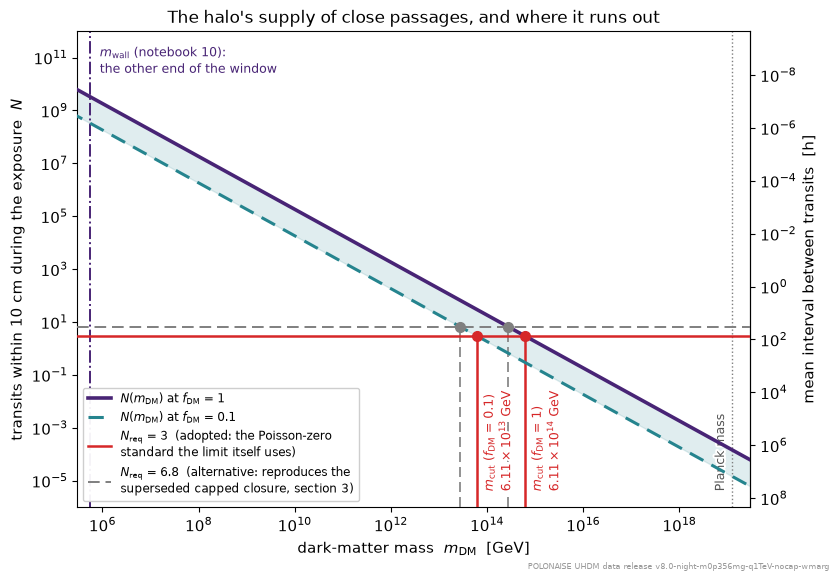

In [2]:
MS = np.geomspace(2e5, 3e19, 400)
CUTS = [(1.0, N_REQ), (1.0, N_REQ_ALT), (0.1, N_REQ), (0.1, N_REQ_ALT)]

print(f"{'m [GeV]':>11} {'N (f=1)':>11} {'N (f=0.1)':>11} "
      f"{'mean interval':>16}")
for m in (1e8, 1e12, mass_cut(1.0, N_REQ_ALT), mass_cut(1.0, N_REQ), 1e15,
          M_PLANCK):
    gap_h = T_TOTAL / n_transits(m, 1.0) / 3600
    gap = (f"{gap_h * 3600 * 1e3:.0f} ms" if gap_h < 1 / 60 else
           f"{gap_h * 60:.1f} min" if gap_h < 1 else
           f"{gap_h:.0f} h" if gap_h < 8766 else
           f"{gap_h / 8766:.0f} yr")
    print(f"{m:>11.3e} {n_transits(m, 1.0):>11.3e} "
          f"{n_transits(m, 0.1):>11.3e} {gap:>16}")

# --- figure 1: the transit curve and the two candidate cuts -----------------
fig, ax = plt.subplots(figsize=(8.4, 5.8))
ax.set_xscale("log")
ax.set_yscale("log")
YLIM = (1e-6, 1e12)

ax.fill_between(MS, n_transits(MS, 0.1), n_transits(MS, 1.0), color=C_MID,
                alpha=0.14, zorder=1)
ax.plot(MS, n_transits(MS, 1.0), color=C_DARK, lw=2.6, zorder=5,
        label=r"$N(m_\mathrm{DM})$ at $f_\mathrm{DM}$ = 1")
ax.plot(MS, n_transits(MS, 0.1), color=C_MID, lw=2.2, ls=(0, (5, 3)), zorder=5,
        label=r"$N(m_\mathrm{DM})$ at $f_\mathrm{DM}$ = 0.1")

# the two candidate requirements
ax.axhline(N_REQ, color=C_RED, lw=1.8, zorder=4,
           label=f"$N_\\mathrm{{req}}$ = {N_REQ:g}  (adopted: the Poisson-zero"
                 "\nstandard the limit itself uses)")
ax.axhline(N_REQ_ALT, color=C_GRAY, lw=1.4, ls=(0, (6, 3)), zorder=4,
           label=f"$N_\\mathrm{{req}}$ = {N_REQ_ALT:g}  (alternative: "
                 "reproduces the\nsuperseded capped closure, section 3)")

# the four cut masses
for f_dm, n_req in CUTS:
    m_c = mass_cut(f_dm, n_req)
    adopted = n_req == N_REQ
    col = C_RED if adopted else C_GRAY
    ax.plot([m_c, m_c], [YLIM[0], n_req], color=col, lw=1.8 if adopted else 1.2,
            ls="-" if adopted else (0, (6, 3)), zorder=3)
    ax.plot([m_c], [n_req], "o", ms=7, color=col, zorder=6)
for f_dm in (1.0, 0.1):
    m_c = mass_cut(f_dm, N_REQ)
    halo_text(ax.text(m_c * 1.25, 4e-6,
                      f"$m_\\mathrm{{cut}}$ ($f_\\mathrm{{DM}}$ = {f_dm:g})\n"
                      f"{fmt_pow(m_c)} GeV",
                      fontsize=9, color=C_RED, ha="left", va="bottom",
                      rotation=90), 3.0)

# the sensor's own scale, and the Planck mass
ax.axvline(M_PLANCK, color=C_GRAY, lw=1.0, ls=":", zorder=2)
halo_text(ax.text(M_PLANCK * 0.8, 4e-6, "Planck mass", fontsize=9,
                  color=C_GUIDE, ha="right", va="bottom", rotation=90), 2.8)
ax.axvline(M_WALL, color=C_DARK, lw=1.4, ls="-.", zorder=2)
halo_text(ax.text(M_WALL * 1.6, 3e11,
                  "$m_\\mathrm{wall}$ (notebook 10):\nthe other end of the "
                  "window", fontsize=9, color=C_DARK, ha="left",
                  va="top"), 3.0)

# the mean interval between transits, on the right
sec = ax.secondary_yaxis(
    "right", functions=(lambda n: T_TOTAL / np.maximum(n, 1e-300) / 3600,
                        lambda h: T_TOTAL / np.maximum(h, 1e-300) / 3600))
sec.set_ylabel("mean interval between transits  [h]")

ax.set_xlim(3e5, 3e19)
ax.set_ylim(*YLIM)
ax.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
ax.set_ylabel(f"transits within {B_CAP * 100:g} cm during the exposure  $N$")
ax.set_title("The halo's supply of close passages, and where it runs out")
ax.legend(loc="lower left", fontsize=8.4, framealpha=0.95)
fig.tight_layout()
save_figure(fig, "11_transit_curve")
plt.show()

## 2. The uncapped contour against the cut

Everything in this section is the mode-1 band, drawn from both released files.
Mode 1 is the one the Letter's mass window is quoted from; the other two modes
have their own bands and their own endpoints, and the mode ordering is not fixed
across builds, so the panels below say which mode they are.

The released surfaces do not close on the right. For the massless mediator the
95% CL band is still non-empty at $1.22\times10^{19}$ GeV, the last mass on the
grid, in both files: nothing in the uncapped cross section ever stops working,
so the exclusion runs off the end of the axis. What the band does do is climb —
at fixed $\mu$ the count scales as $\alpha_n^{2}/m_\mathrm{DM}$, so the floor of
the band rises roughly as $\sqrt{m_\mathrm{DM}}$, from
$3.1\times10^{-9}$ at its deepest to $1.1\times10^{-5}$ where the cut falls.

$m_\mathrm{cut}$ is where that surface stops being a claim. Beyond it the halo
supplies fewer than $N_\mathrm{req}$ expected transits within 10 cm during the
exposure, so the excluded region there is an extrapolation of the cross section
into a regime the exposure never sampled.

The finite-range slices are a different story: they close on their own, and far
below the cut. A Yukawa of range $\lambda$ delivers no impulse to an impact
parameter much beyond $\lambda$, so as the mass rises the coupling needed
outruns the grid long before the flux argument bites — 2 mm closes at
$5.7\times10^{12}$ GeV, 200 µm at $5.4\times10^{10}$, 20 µm at
$6.6\times10^{8}$. The flux cut therefore only ever touches the massless
(Coulomb-reach) surface, which is the one the Letter's mass window is quoted
from.

massless mediator, mode 1: right end of the released band
  f_DM = 1, atm        last excluded grid mass 1.2200e+19 GeV (grid top 1.2200e+19);  m_cut = 6.1107e+14
  f_DM = 0.1, no atm   last excluded grid mass 1.2200e+19 GeV (grid top 1.2200e+19);  m_cut = 6.1107e+13

finite ranges close on their own, well below the cut:
  f_DM = 1, atm        2mm    : closes at 5.7469e+12 GeV (9.4e-03 x m_cut)
  f_DM = 1, atm        200um  : closes at 7.0700e+10 GeV (1.2e-04 x m_cut)
  f_DM = 1, atm        20um   : closes at 6.6074e+08 GeV (1.1e-06 x m_cut)
  f_DM = 0.1, no atm   2mm    : closes at 1.1045e+12 GeV (1.8e-02 x m_cut)
  f_DM = 0.1, no atm   200um  : closes at 1.0323e+10 GeV (1.7e-04 x m_cut)
  f_DM = 0.1, no atm   20um   : closes at 4.2293e+07 GeV (6.9e-07 x m_cut)

band floor at the cut (f_DM = 1): alpha_n = 1.097e-05 at m = 6.1493e+14; deepest floor 3.065e-09


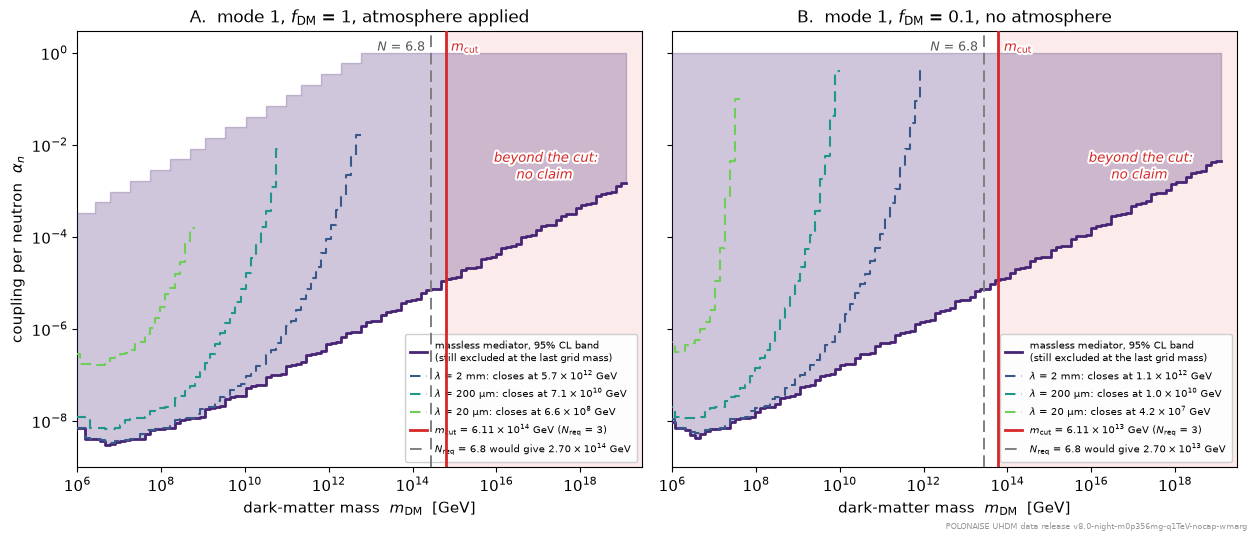

In [3]:
LO_A, HI_A = band_of(rel, "massless", 1.0, True)
LO_B, HI_B = band_of(relB, "massless", 0.1, False)

print(f"massless mediator, mode {MODE}: right end of the released band")
for tag, lo, f_dm in (("f_DM = 1, atm", LO_A, 1.0),
                      ("f_DM = 0.1, no atm", LO_B, 0.1)):
    ok = np.where(np.isfinite(lo))[0]
    print(f"  {tag:20s} last excluded grid mass {MS_GRID[ok[-1]]:.4e} GeV "
          f"(grid top {MS_GRID[-1]:.4e});  m_cut = "
          f"{mass_cut(f_dm, N_REQ):.4e}")

print("\nfinite ranges close on their own, well below the cut:")
CLOSURES = {}
for tag, r, f_dm, atmo in (("f_DM = 1, atm", rel, 1.0, True),
                           ("f_DM = 0.1, no atm", relB, 0.1, False)):
    for lam in LAMBDAS[1:]:
        lo, _ = band_of(r, lam, f_dm, atmo)
        ok = np.where(np.isfinite(lo))[0]
        m_close = float(r.axes.mass_gev[ok[-1]])
        CLOSURES[(f_dm, lam)] = m_close
        print(f"  {tag:20s} {lam:7s}: closes at {m_close:.4e} GeV "
              f"({m_close / mass_cut(f_dm, N_REQ):.1e} x m_cut)")

i_cut = int(np.argmin(np.abs(MS_GRID - mass_cut(1.0, N_REQ))))
print(f"\nband floor at the cut (f_DM = 1): alpha_n = {LO_A[i_cut]:.3e} "
      f"at m = {MS_GRID[i_cut]:.4e}; deepest floor {np.nanmin(LO_A):.3e}")

# --- figure 2: the uncapped band and the cut, for both files ----------------
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.4), sharey=True)
PANELS = [(axes[0], f"A.  mode {MODE}, $f_\\mathrm{{DM}}$ = 1, atmosphere "
           "applied", LO_A, HI_A, 1.0),
          (axes[1], f"B.  mode {MODE}, $f_\\mathrm{{DM}}$ = 0.1, no "
           "atmosphere", LO_B, HI_B, 0.1)]

for ax, title, lo, hi, f_dm in PANELS:
    ax.set_xscale("log")
    ax.set_yscale("log")
    m_c, m_c_alt = mass_cut(f_dm, N_REQ), mass_cut(f_dm, N_REQ_ALT)
    ok = np.isfinite(lo)
    ax.fill_between(MS_GRID[ok], lo[ok], hi[ok], color=C_DARK, alpha=0.26,
                    step="pre", zorder=3)
    ax.step(MS_GRID[ok], lo[ok], where="pre", color=C_DARK, lw=2.0, zorder=4,
            label="massless mediator, 95% CL band\n"
                  "(still excluded at the last grid mass)")

    # the finite ranges, which close on their own
    for lam in LAMBDAS[1:]:
        lo_l, _ = band_of(rel if f_dm == 1.0 else relB, lam, f_dm,
                          f_dm == 1.0)
        okl = np.isfinite(lo_l)
        ax.step(MS_GRID[okl], lo_l[okl], where="pre", color=LAM_COL[lam],
                lw=1.5, ls=(0, (5, 3)), zorder=5,
                label=f"{LAM_LABEL[lam]}: closes at "
                      f"{fmt_pow(MS_GRID[okl][-1], 1)} GeV")

    # beyond the cut: no claim
    ax.axvspan(m_c, 1e20, color=C_RED, alpha=0.09, zorder=1)
    ax.axvline(m_c, color=C_RED, lw=2.0, zorder=6,
               label=f"$m_\\mathrm{{cut}}$ = {fmt_pow(m_c)} GeV "
                     f"($N_\\mathrm{{req}}$ = {N_REQ:g})")
    ax.axvline(m_c_alt, color=C_GRAY, lw=1.4, ls=(0, (6, 3)), zorder=6,
               label=f"$N_\\mathrm{{req}}$ = {N_REQ_ALT:g} would give "
                     f"{fmt_pow(m_c_alt)} GeV")
    halo_text(ax.text(m_c * 1.35, 1.85, "$m_\\mathrm{cut}$", fontsize=9.5,
                      color=C_RED, ha="left", va="top"), 3.0)
    halo_text(ax.text(m_c_alt * 0.75, 1.85, f"$N$ = {N_REQ_ALT:g}",
                      fontsize=9, color=C_GUIDE, ha="right", va="top"), 3.0)
    halo_text(ax.text(1.4e17, 8e-3, "beyond the cut:\nno claim", fontsize=9.5,
                      color=C_RED, ha="center", va="top", style="italic"), 3.0)
    ax.set_xlim(1e6, 3e19)
    ax.set_ylim(1e-9, 3.0)
    ax.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=7.4, framealpha=0.95,
              handlelength=1.6, borderpad=0.5)

axes[0].set_ylabel(r"coupling per neutron  $\alpha_n$")
fig.tight_layout()
save_figure(fig, "11_contour_vs_cut")
plt.show()

## 3. The superseded capped closure, and what $N_\mathrm{req}$ buys

The earlier analysis reached the same physical conclusion by a different route.
It clipped the outer edge of the impact-parameter integral at
$b \le b_\mathrm{cap} = 10$ cm inside the cross section itself, so the counted
rate came only from flybys within the aperture. That version *did* close on the
right, at $2.70\times10^{14}$ GeV for $f_\mathrm{DM} = 1$ — and it closed for
precisely the reason the flux argument names, since a capped $b$-integral has a
finite geometric cross section and the transit supply is what it runs out of.
That cube is an internal file rather than part of the release, so its band is
not redrawn here; the two closure masses it contributes are frozen constants in
the setup cell, and everything else in this section is arithmetic on top of
them.

The two routes differ in bookkeeping, not in mechanism, and the flux cut is the
more honest of the two. A cap inside the cross section changes the shape of
$d\sigma/dq$ everywhere, not only at high mass — it removes the soft flybys,
grows a projection horn at $q_* = 2\alpha/(v\,b_\mathrm{cap})$ (drawn in
`png/07_impact_parameter_cap.png`) and
so alters the limit at masses where the transit supply is in the millions and
nothing needed to be cut. Applying the same physics afterwards, as a line in
mass, leaves every stored surface uncapped and puts the choice where a reader
can see it.

Where they differ is *how many* transits the earlier closure implicitly
demanded. Solving $N(m) = N_\mathrm{req}$ at the capped closure mass gives
$N_\mathrm{req} = 6.80$: the capped analysis stopped claiming when the halo
still supplied about seven expected passages, a little more than twice as strict
as the Poisson-zero standard. In mass the difference is a factor 2.27, or 0.36
of a decade — small on the scale of the nine-decade window, and the reason both
lines are worth drawing rather than arguing about. The calibration is only good
to about a grid step: the same exercise on the $f_\mathrm{DM} = 0.1$ capped
closure lands one mass grid point lower and reads $N_\mathrm{req} = 8.1$, and
the grid spacing is a factor 1.32.

$m_\mathrm{cut} \propto 1/N_\mathrm{req}$, so the whole family is one line on
log axes; panel B draws it, with the two candidate values and the capped
closure marked.

superseded capped analysis: v5.0-night-m0p356mg-bcap10cm   b_constrained_max = 0.1 m   q_thresh = 100 GeV
  (internal cube, not part of the release; its two mode-1 massless closure masses are frozen in the setup cell)
  f_DM =    1: capped closure at 2.6959e+14 GeV  ->  implies N_req = 6.80
  f_DM =  0.1: capped closure at 2.2715e+13 GeV  ->  implies N_req = 8.07

  N_req    m_cut (f=1)  m_cut (f=0.1)  note
      1     1.8332e+15     1.8332e+14  
      3     6.1107e+14     6.1107e+13  adopted (Poisson-zero standard)
    6.8     2.6959e+14     2.6959e+13  reproduces the superseded capped closure
     10     1.8332e+14     1.8332e+13  
    100     1.8332e+13     1.8332e+12  

ratio m_cut(N=3)/m_cut(N=6.8) = 2.27 = 0.36 decades


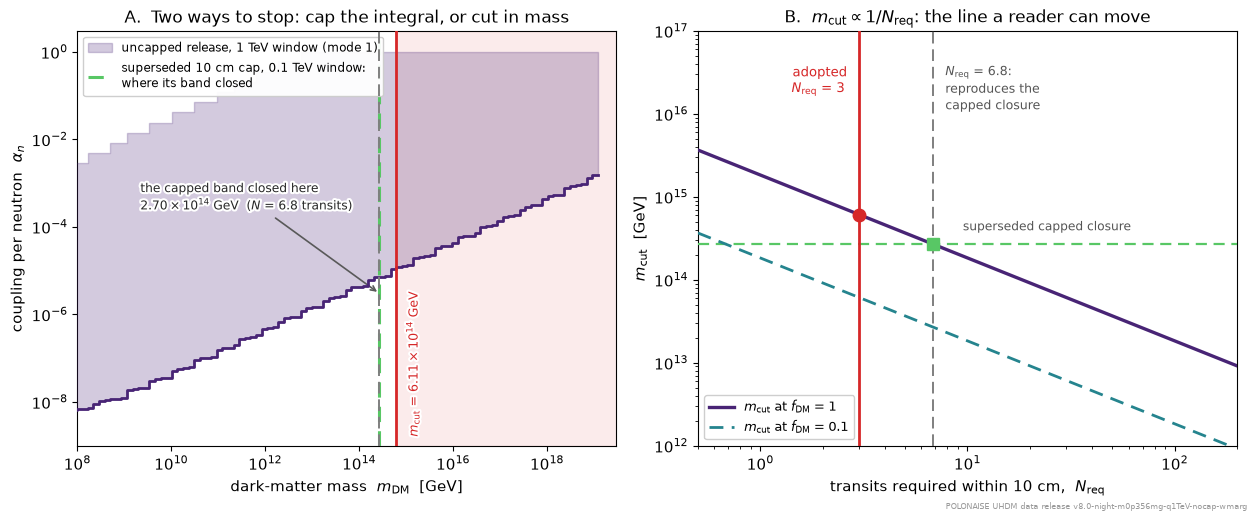

In [4]:
print(f"superseded capped analysis: {CAPPED_TAG}   b_constrained_max = "
      f"{B_CAP:g} m   q_thresh = {CAPPED_WINDOW_GEV:.0f} GeV")
print("  (internal cube, not part of the release; its two mode-1 massless "
      "closure masses are frozen in the setup cell)")
for f_dm in (1.0, 0.1):
    n_implied = n_transits(M_CLOSE_CAPPED[f_dm], f_dm)
    print(f"  f_DM = {f_dm:>4g}: capped closure at "
          f"{M_CLOSE_CAPPED[f_dm]:.4e} GeV  ->  implies N_req = "
          f"{n_implied:.2f}")

print(f"\n{'N_req':>7} {'m_cut (f=1)':>14} {'m_cut (f=0.1)':>14}  note")
for n_req in (1.0, 3.0, 6.8, 10.0, 100.0):
    note = ""
    if n_req == N_REQ:
        note = "adopted (Poisson-zero standard)"
    elif n_req == N_REQ_ALT:
        note = "reproduces the superseded capped closure"
    print(f"{n_req:>7g} {mass_cut(1.0, n_req):>14.4e} "
          f"{mass_cut(0.1, n_req):>14.4e}  {note}")
print(f"\nratio m_cut(N=3)/m_cut(N=6.8) = {N_REQ_ALT / N_REQ:.2f} "
      f"= {np.log10(N_REQ_ALT / N_REQ):.2f} decades")

# --- figure 3: the capped closure and the N_req family ----------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.6, 5.2))

# --- A: the two schemes at the high-mass end (f_DM = 1) ---
axA.set_xscale("log")
axA.set_yscale("log")
ok = np.isfinite(LO_A)
axA.fill_between(MS_GRID[ok], LO_A[ok], HI_A[ok], color=C_DARK, alpha=0.24,
                 step="pre", zorder=3,
                 label=f"uncapped release, 1 TeV window (mode {MODE})")
axA.step(MS_GRID[ok], LO_A[ok], where="pre", color=C_DARK, lw=2.0, zorder=4)
# The capped band itself is not drawn: that cube is internal and not shipped.
# Only its closure mass is carried, as a frozen constant.
m5 = M_CLOSE_CAPPED[1.0]
axA.axvline(m5, color=C_LIGHT, lw=2.2, ls=(0, (5, 3)), zorder=5,
            label="superseded 10 cm cap, 0.1 TeV window:\n"
                  "where its band closed")
an = axA.annotate(f"the capped band closed here\n{fmt_pow(m5)} GeV  "
                  f"($N$ = {n_transits(m5, 1.0):.1f} transits)",
                  xy=(m5, 3.0e-6), xytext=(2.2e9, 2.0e-4), fontsize=8.8,
                  color="0.15", ha="left", va="bottom",
                  arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
halo_text(an, 3.0)
m_c = mass_cut(1.0, N_REQ)
axA.axvspan(m_c, 1e20, color=C_RED, alpha=0.09, zorder=1)
axA.axvline(m_c, color=C_RED, lw=2.0, zorder=6)
halo_text(axA.text(m_c * 1.6, 1.6e-9,
                   f"$m_\\mathrm{{cut}}$ = {fmt_pow(m_c)} GeV", fontsize=9,
                   color=C_RED, ha="left", va="bottom", rotation=90), 3.0)
axA.axvline(mass_cut(1.0, N_REQ_ALT), color=C_GRAY, lw=1.4, ls=(0, (6, 3)),
            zorder=6)
axA.set_xlim(1e8, 3e19)
axA.set_ylim(1e-9, 3.0)
axA.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
axA.set_ylabel(r"coupling per neutron  $\alpha_n$")
axA.set_title("A.  Two ways to stop: cap the integral, or cut in mass")
axA.legend(loc="upper left", fontsize=8.6, framealpha=0.95)

# --- B: the whole N_req family ---
axB.set_xscale("log")
axB.set_yscale("log")
NN = np.geomspace(0.5, 200, 300)
axB.plot(NN, mass_cut(1.0, NN), color=C_DARK, lw=2.4, zorder=4,
         label=r"$m_\mathrm{cut}$ at $f_\mathrm{DM}$ = 1")
axB.plot(NN, mass_cut(0.1, NN), color=C_MID, lw=2.0, ls=(0, (5, 3)), zorder=4,
         label=r"$m_\mathrm{cut}$ at $f_\mathrm{DM}$ = 0.1")
axB.axvline(N_REQ, color=C_RED, lw=2.0, zorder=5)
axB.plot([N_REQ], [mass_cut(1.0, N_REQ)], "o", ms=9, color=C_RED, zorder=7)
halo_text(axB.text(N_REQ * 0.86, 4e16,
                   f"adopted\n$N_\\mathrm{{req}}$ = {N_REQ:g}", fontsize=9.5,
                   color=C_RED, ha="right", va="top"), 3.0)
axB.axvline(N_REQ_ALT, color=C_GRAY, lw=1.4, ls=(0, (6, 3)), zorder=5)
halo_text(axB.text(N_REQ_ALT * 1.15, 4e16,
                   f"$N_\\mathrm{{req}}$ = {N_REQ_ALT:g}:\nreproduces the\n"
                   "capped closure", fontsize=9, color=C_GUIDE, ha="left",
                   va="top"), 3.0)
axB.axhline(M_CLOSE_CAPPED[1.0], color=C_LIGHT, lw=1.6, ls=(0, (5, 3)),
            zorder=3)
axB.plot([N_REQ_ALT], [M_CLOSE_CAPPED[1.0]], "s", ms=8, color=C_LIGHT,
         zorder=7)
halo_text(axB.text(60, M_CLOSE_CAPPED[1.0] * 1.35,
                   "superseded capped closure", fontsize=8.8,
                   color=C_GUIDE, ha="right", va="bottom"), 3.0)
axB.set_xlim(NN[0], NN[-1])
axB.set_ylim(1e12, 1e17)
axB.set_xlabel(r"transits required within 10 cm,  $N_\mathrm{req}$")
axB.set_ylabel(r"$m_\mathrm{cut}$  [GeV]")
axB.set_title(r"B.  $m_\mathrm{cut} \propto 1/N_\mathrm{req}$: the line a "
              "reader can move")
axB.legend(loc="lower left", fontsize=9, framealpha=0.95)

fig.tight_layout()
save_figure(fig, "11_capped_vs_flux_cut")
plt.show()

## 4. The shell of validity: why the aperture is 10 cm

Nothing so far explains the choice $b_\mathrm{cap} = 10$ cm. It is not a
property of the halo and not a property of the cross section; it is the scale of
the apparatus, and it is where the *measurement* changes character.

A flyby at impact parameter $b$ pulls on everything within roughly $b$ of it.
While $b$ is small compared with the hardware, that means the levitated magnet
and nothing else: the magnet is accelerated relative to its trap, and the
differential read-out records an impulse. Once $b$ grows past the scale of the
apparatus the same flyby pulls on the magnet *and* on the trap that defines its
zero — the two see nearly the same acceleration, the response becomes
common-mode, and a differential read-out suppresses it. It does not become
zero — the residual goes as the gradient of the field across the instrument
rather than the field itself — but the analysis has no calibration for that
regime and does not model it. Ten centimetres is the honest outer edge of the
shell the detector was characterised in, so it is the aperture the supply
argument is asked about.

That is a separate statement from the flux cut, and it is worth seeing where the
two meet on the surface. The threshold reach — the largest impact parameter that
still delivers $q_\mathrm{min}$ — is stored in the release as the flux-averaged
$b_\mathrm{max}$ on the halo grid, and above the wall it depends only on the
coupling. It equals the sensor radius $R_\mathrm{eff}$ = 260 µm at
$\alpha_n = 5.3\times10^{-9}$ — within a factor of two of the deepest point of
the exclusion floor, $\alpha_n = 3.1\times10^{-9}$, though the two are separate
quantities and only the reach is fixed by the halo grid — and it reaches 10 cm
at $\alpha_n = 1.7\times10^{-6}$. Between those two it is simply linear,
$b_\mathrm{max} = 2\alpha/(q_\mathrm{min}v)$ flux-averaged over $v$; below
$R_\mathrm{eff}$ it falls away faster, because only the slowest flybys still
clear the sensor radius and the halo has few of those.

Because the floor of the band climbs with mass, the couplings that carry the
exclusion cross that value around $m_\mathrm{DM} = 2.3\times10^{13}$ GeV.
Above that mass every excluded coupling has a threshold reach larger than the
apparatus, so the counted rate there is dominated by flybys the differential
read-out would suppress. This notebook does not turn that into a second cut —
the released window is bounded by $m_\mathrm{cut}$ and nothing else — but it is
the reason the aperture in the flux argument is a hardware scale rather than a
free parameter, and it is a caveat to carry when reading the top decade and a
half below $m_\mathrm{cut}$.

threshold reach = R_eff = 260 um at alpha_n = 5.313e-09
threshold reach = b_cap = 10 cm at alpha_n = 1.729e-06
the band floor's reach first exceeds 10 cm at m = 2.272e+13 GeV (alpha_n = 2.03e-06)
  at m = 2.696e+14: floor alpha_n = 7.06e-06, reach = 0.408 m = 4.1 x b_cap
  at m = 6.149e+14: floor alpha_n = 1.10e-05, reach = 0.634 m = 6.3 x b_cap


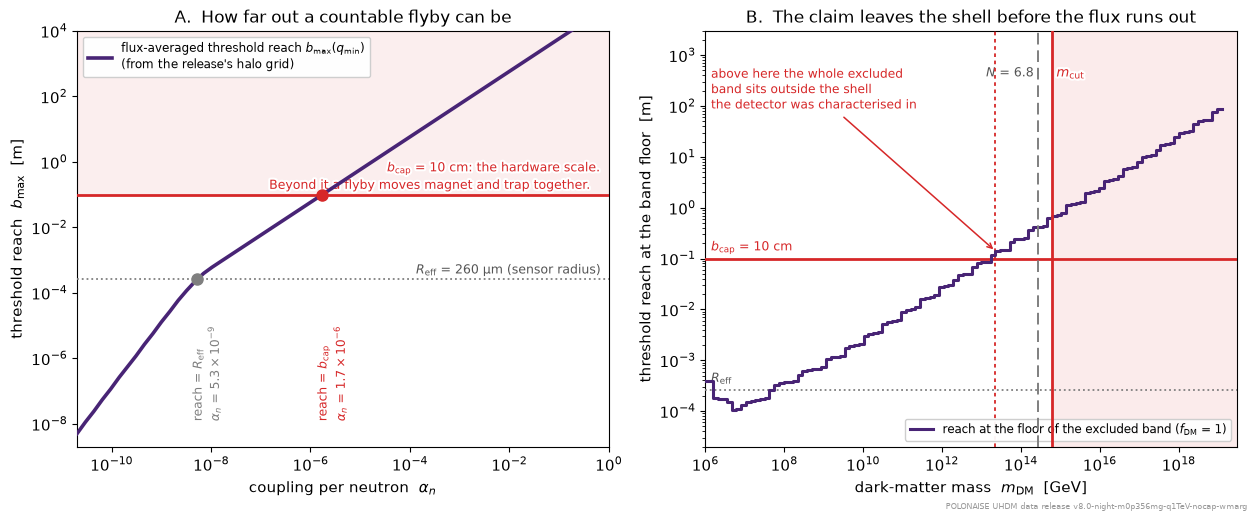

In [5]:
# the flux-averaged threshold reach, from the cube's own halo grid
BMAX = rel.mass_plane("bmax", mode=None, lam="massless", group="halo")
A_HALO = rel.axes_halo.alpha_n
M_HALO = rel.axes_halo.mass_gev
i_heavy = M_HALO.size - 10            # any mass well above the wall: b is
reach = BMAX[:, i_heavy]              # mass-independent there
ok = reach > 0
assert np.allclose(reach[:, None], BMAX[:, M_HALO > 1e12],
                   rtol=1e-6), "threshold reach is not mass-independent"


def alpha_at_reach(b_m):
    """Coupling whose flux-averaged threshold reach is b_m [m]."""
    return float(np.exp(np.interp(np.log(b_m), np.log(reach[ok]),
                                  np.log(A_HALO[ok]))))


def reach_at_alpha(a_n):
    """Flux-averaged threshold reach [m] at this coupling."""
    return np.exp(np.interp(np.log(a_n), np.log(A_HALO[ok]),
                            np.log(reach[ok])))


A_SHELL = alpha_at_reach(B_CAP)
A_REFF = alpha_at_reach(R_EFF)
print(f"threshold reach = R_eff = {R_EFF * 1e6:.0f} um at alpha_n = "
      f"{A_REFF:.3e}")
print(f"threshold reach = b_cap = {B_CAP * 100:g} cm at alpha_n = "
      f"{A_SHELL:.3e}")

reach_floor = reach_at_alpha(LO_A)
sel = np.isfinite(LO_A)
i_shell = int(np.where(sel & (reach_floor > B_CAP))[0][0])
print(f"the band floor's reach first exceeds {B_CAP * 100:g} cm at "
      f"m = {MS_GRID[i_shell]:.3e} GeV (alpha_n = {LO_A[i_shell]:.2e})")
for m_t in (mass_cut(1.0, N_REQ_ALT), mass_cut(1.0, N_REQ)):
    i_t = int(np.argmin(np.abs(MS_GRID - m_t)))
    print(f"  at m = {MS_GRID[i_t]:.3e}: floor alpha_n = {LO_A[i_t]:.2e}, "
          f"reach = {reach_floor[i_t]:.3f} m = "
          f"{reach_floor[i_t] / B_CAP:.1f} x b_cap")

# --- figure 4: the reach against the hardware scale -------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.6, 5.2))

# --- A: reach vs coupling ---
axA.set_xscale("log")
axA.set_yscale("log")
axA.fill_between(A_HALO[ok], B_CAP, 1e4, color=C_RED, alpha=0.08, zorder=1)
axA.plot(A_HALO[ok], reach[ok], color=C_DARK, lw=2.6, zorder=5,
         label="flux-averaged threshold reach $b_\\mathrm{max}(q_\\mathrm{min})$"
               "\n(from the release's halo grid)")
axA.axhline(B_CAP, color=C_RED, lw=2.0, zorder=4)
halo_text(axA.text(0.7, B_CAP * 1.5,
                   f"$b_\\mathrm{{cap}}$ = {B_CAP * 100:g} cm: the hardware "
                   "scale.\nBeyond it a flyby moves magnet and trap together.",
                   fontsize=9, color=C_RED, ha="right"), 3.0)
axA.axhline(R_EFF, color=C_GRAY, lw=1.3, ls=":", zorder=4)
halo_text(axA.text(0.7, R_EFF * 1.5,
                   f"$R_\\mathrm{{eff}}$ = {R_EFF * 1e6:.0f} µm (sensor radius)",
                   fontsize=9, color=C_GUIDE, ha="right"), 2.8)
for a_v, lab, col in ((A_REFF, "reach = $R_\\mathrm{eff}$", C_GRAY),
                      (A_SHELL, "reach = $b_\\mathrm{cap}$", C_RED)):
    axA.plot([a_v], [reach_at_alpha(a_v)], "o", ms=8, color=col, zorder=6)
    halo_text(axA.text(a_v * 0.72, 1.2e-8, f"{lab}\n$\\alpha_n$ = "
                       f"{fmt_pow(a_v, 1)}", fontsize=8.8, color=col,
                       ha="left", va="bottom", rotation=90), 3.0)
axA.set_xlim(2e-11, 1.0)
axA.set_ylim(2e-9, 1e4)
axA.set_xlabel(r"coupling per neutron  $\alpha_n$")
axA.set_ylabel(r"threshold reach  $b_\mathrm{max}$  [m]")
axA.set_title("A.  How far out a countable flyby can be")
axA.legend(loc="upper left", fontsize=8.6, framealpha=0.95)

# --- B: the reach the exclusion floor actually uses, vs mass ---
axB.set_xscale("log")
axB.set_yscale("log")
m_c = mass_cut(1.0, N_REQ)
axB.axvspan(m_c, 1e20, color=C_RED, alpha=0.09, zorder=1)
axB.step(MS_GRID[sel], reach_floor[sel], where="pre", color=C_DARK, lw=2.2,
         zorder=5, label="reach at the floor of the excluded band "
                         "($f_\\mathrm{DM}$ = 1)")
axB.axhline(B_CAP, color=C_RED, lw=2.0, zorder=4)
halo_text(axB.text(1.4e6, B_CAP * 1.45,
                   f"$b_\\mathrm{{cap}}$ = {B_CAP * 100:g} cm", fontsize=9,
                   color=C_RED), 3.0)
axB.axhline(R_EFF, color=C_GRAY, lw=1.3, ls=":", zorder=4)
halo_text(axB.text(1.4e6, R_EFF * 1.45, "$R_\\mathrm{eff}$", fontsize=9,
                   color=C_GUIDE), 2.8)
axB.axvline(MS_GRID[i_shell], color=C_RED, lw=1.3, ls=(0, (2, 2)), zorder=4)
an = axB.annotate("above here the whole excluded\nband sits outside the shell\n"
                  "the detector was characterised in",
                  xy=(MS_GRID[i_shell], 0.14), xytext=(1.4e6, 6e2),
                  fontsize=8.8, color=C_RED, ha="left", va="top",
                  arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.1))
halo_text(an, 3.0)
axB.axvline(m_c, color=C_RED, lw=2.0, zorder=6)
halo_text(axB.text(m_c * 1.3, 6e2, "$m_\\mathrm{cut}$", fontsize=9.5,
                   color=C_RED, ha="left", va="top"), 3.0)
axB.axvline(mass_cut(1.0, N_REQ_ALT), color=C_GRAY, lw=1.4, ls=(0, (6, 3)),
            zorder=6)
halo_text(axB.text(mass_cut(1.0, N_REQ_ALT) * 0.8, 6e2, f"$N$ = {N_REQ_ALT:g}",
                   fontsize=9, color=C_GUIDE, ha="right", va="top"), 3.0)
axB.set_xlim(1e6, 3e19)
axB.set_ylim(2e-5, 3e3)
axB.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
axB.set_ylabel(r"threshold reach at the band floor  [m]")
axB.set_title("B.  The claim leaves the shell before the flux runs out")
axB.legend(loc="lower right", fontsize=8.4, framealpha=0.95)

fig.tight_layout()
save_figure(fig, "11_shell_of_validity")
plt.show()

## 5. Numerical self-consistency checks

1. $m_\mathrm{cut}$ recomputed here reproduces the value stored in each file's
   attributes, bit for bit at float precision, and $\langle v \rangle$ matches
   the number quoted in the file's own derivation string.
2. $N(m_\mathrm{cut}) = N_\mathrm{req}$ exactly, and $m_\mathrm{cut}$ scales
   linearly with $f_\mathrm{DM}$.
3. The cut is *not* baked into the stored surfaces: the attribute says so, and
   the massless band is still excluded at the last grid mass, past the cut.
4. $N_\mathrm{req} = 6.80$ reproduces the frozen capped closure mass to better
   than a percent.
5. The finite-range slices close on their own below $m_\mathrm{cut}$, so the cut
   only ever touches the massless surface.
6. The threshold reach stored on the halo grid is mass-independent above the
   wall and linear in the coupling, as the Coulomb form
   $b_\mathrm{max} = 2\alpha/(q_\mathrm{min} v)$ requires.

In [6]:
# 1 -- m_cut and <v> against the file attributes
for r, f_dm in ((rel, 1.0), (relB, 0.1)):
    key = f"m_cut_10cm_f{f_dm:g}_gev"
    stored = float(r.attrs[key])
    mine = mass_cut(f_dm, float(r.attrs["m_cut_n_transits_required"]),
                    float(r.attrs["m_cut_b_cap_m"]))
    print(f"1. f_DM = {f_dm:>4g}: stored {stored:.6e}  recomputed {mine:.6e}  "
          f"rel. diff {abs(mine / stored - 1):.1e}")
    assert abs(mine / stored - 1) < 1e-9
deriv = str(rel.attrs["m_cut_10cm_f1_gev_derivation"])
assert f"<v> = {V_MEAN:.6g} m/s" in deriv, deriv
print(f"   <v> = {V_MEAN:.6g} m/s matches the file's derivation string")

# 2 -- the definition closes on itself, and scales with f_DM
for f_dm in (1.0, 0.1):
    for n_req in (N_REQ, N_REQ_ALT):
        assert abs(n_transits(mass_cut(f_dm, n_req), f_dm) / n_req - 1) < 1e-12
print(f"2. N(m_cut) = N_req exactly for both requirements and both fractions; "
      f"m_cut(1.0)/m_cut(0.1) = "
      f"{mass_cut(1.0, N_REQ) / mass_cut(0.1, N_REQ):.1f}")
assert abs(mass_cut(1.0, N_REQ) / mass_cut(0.1, N_REQ) - 10.0) < 1e-9

# 3 -- uncapped surfaces, cut not applied
last_A = MS_GRID[np.where(np.isfinite(LO_A))[0][-1]]
print(f"3. m_cut_applied_to_stored_surfaces = "
      f"{bool(rel.attrs['m_cut_applied_to_stored_surfaces'])}; "
      f"last excluded grid mass {last_A:.3e} GeV is "
      f"{last_A / mass_cut(1.0, N_REQ):.0f}x past the cut")
assert not bool(rel.attrs["m_cut_applied_to_stored_surfaces"])
assert last_A > mass_cut(1.0, N_REQ)

# 4 -- the frozen capped closure calibrates N_req = 6.8
n_implied = n_transits(M_CLOSE_CAPPED[1.0], 1.0)
print(f"4. capped closure {M_CLOSE_CAPPED[1.0]:.4e} GeV implies "
      f"N_req = {n_implied:.3f} (quoted {N_REQ_ALT:g}, "
      f"{abs(n_implied / N_REQ_ALT - 1) * 100:.2f}% apart)")
assert abs(n_implied / N_REQ_ALT - 1) < 0.01

# 5 -- finite ranges close first
for (f_dm, lam), m_close in CLOSURES.items():
    assert m_close < mass_cut(f_dm, N_REQ)
print(f"5. all {len(CLOSURES)} finite-range slices close below their m_cut; "
      f"the largest is {max(CLOSURES.values()):.3e} GeV")

# 6 -- the reach is mass-blind, and Coulomb-linear once it clears R_eff
lin = reach > 10 * R_EFF
ratios = reach[lin] / A_HALO[lin]
print(f"6. b_max is identical across all {int((M_HALO > 1e12).sum())} masses "
      f"above 1e12 GeV; b_max/alpha_n over the {int(lin.sum())} couplings "
      f"with reach > 10 R_eff: spread {ratios.max() / ratios.min() - 1:.1e}")
assert ratios.max() / ratios.min() - 1 < 1e-4
print("\nall checks passed")

1. f_DM =    1: stored 6.110685e+14  recomputed 6.110685e+14  rel. diff 0.0e+00
1. f_DM =  0.1: stored 6.110685e+13  recomputed 6.110685e+13  rel. diff 0.0e+00
   <v> = 245972 m/s matches the file's derivation string
2. N(m_cut) = N_req exactly for both requirements and both fractions; m_cut(1.0)/m_cut(0.1) = 10.0
3. m_cut_applied_to_stored_surfaces = False; last excluded grid mass 1.220e+19 GeV is 19965x past the cut
4. capped closure 2.6959e+14 GeV implies N_req = 6.800 (quoted 6.8, 0.00% apart)
5. all 6 finite-range slices close below their m_cut; the largest is 5.747e+12 GeV
6. b_max is identical across all 32 masses above 1e12 GeV; b_max/alpha_n over the 44 couplings with reach > 10 R_eff: spread 9.5e-08

all checks passed


## Takeaway

The right edge is a supply statement, and it is arithmetic in the same way the
left edge is:

$$m_\mathrm{cut} \;=\; \frac{f_\mathrm{DM}\,\rho_0\,\langle v \rangle\,
T_\mathrm{obs}\,\pi\,b_\mathrm{cap}^{2}}{N_\mathrm{req}}
\;=\; 6.11\times10^{14}\ \mathrm{GeV}\quad (f_\mathrm{DM} = 1,\
N_\mathrm{req} = 3),$$

and $6.11\times10^{13}$ GeV at $f_\mathrm{DM} = 0.1$. Beyond it the halo
supplies fewer than three expected passages within 10 cm during the 219.7 h
exposure — the same Poisson-zero standard the limit itself is built on — so no
claim is made there, even though the uncapped surfaces remain formally excluded
all the way to the Planck mass.

$N_\mathrm{req} = 3$ is an assumption. The alternative worth knowing is
$N_\mathrm{req} = 6.8$, the implicit requirement of the superseded analysis that
capped the impact-parameter integral instead; it moves the cut to
$2.70\times10^{14}$ GeV, 0.36 of a decade lower. Since $m_\mathrm{cut} \propto
1/N_\mathrm{req}$ and the stored surfaces are uncapped, moving the line is a
one-number edit, which is the point of applying the argument after the fact
rather than inside the cross section.

Two things bound the reading of the far right. The flux cut is one. The other is
the shell the detector was characterised in: the threshold reach passes 10 cm at
$\alpha_n \approx 1.7\times10^{-6}$, and the floor of the excluded band passes
that coupling at $2.3\times10^{13}$ GeV, so in the top decade and a half below
$m_\mathrm{cut}$ the counted flybys are ones a differential read-out would see
largely as common mode. That is not a second cut and is not applied; it is the
reason the aperture in the supply argument is 10 cm rather than a number chosen
to be convenient.

With both ends in hand, the released mass window at $f_\mathrm{DM} = 1$ runs
from $m_\mathrm{wall} = 5.51\times10^{5}$ GeV to
$m_\mathrm{cut} = 6.11\times10^{14}$ GeV — just over nine decades, bounded at
one end by the escape speed and at the other by the local density.